In [15]:
"""
Monte Carlo Cross-Validation (MCCV) para Classificação de Leucemia
Com randomização completa de pacientes a cada iteração
"""

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
import timm
import pickle
import json
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
import time
from scipy import stats
warnings.filterwarnings('ignore')

In [16]:
# ===================== CONFIGURAÇÕES MONTE CARLO =====================
MONTE_CARLO_ITERATIONS = 100  # Número de iterações Monte Carlo
TEST_SIZE = 0.2  # Proporção para teste em cada iteração
VAL_SIZE = 0.15  # Proporção para validação do conjunto de treino
RANDOM_SEED_BASE = 42  # Seed base para reprodutibilidade

# Configurações do modelo
IMAGE_SIZE = 384
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_CLASSES = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS_PER_ITERATION = 30  # Menos epochs por iteração já que faremos 100x

# Diretórios
TRAIN_DIR = 'dataset/cnmc2019_splits/images/train'
VAL_DIR = 'dataset/cnmc2019_splits/images/val'
TEST_DIR = 'dataset/cnmc2019_splits/images/test'
SAVE_DIR = 'monte_carlo_results_randomized'
os.makedirs(SAVE_DIR, exist_ok=True)

# Modelos a testar
CNN_MODELS = [
    'tf_efficientnetv2_b3'
]

In [17]:
# ===================== DATASET MELHORADO COM RANDOMIZAÇÃO =====================
class LeukemiaDatasetMCRandomized(Dataset):
    """Dataset que carrega TODAS as imagens e permite randomização completa"""
    
    def __init__(self, transform=None):
        self.transform = transform
        self.all_images = []
        self.all_labels = []
        
        # Carregar TODAS as imagens de TODOS os diretórios
        dirs_list = [TRAIN_DIR, VAL_DIR, TEST_DIR]
        
        print("Carregando todas as imagens do dataset...")
        for data_dir in dirs_list:
            # Carregar imagens ALL (classe 1)
            all_dir = os.path.join(data_dir, 'all')
            if os.path.exists(all_dir):
                for img_name in os.listdir(all_dir):
                    if img_name.endswith(('.jpg', '.png', '.bmp')):
                        self.all_images.append(os.path.join(all_dir, img_name))
                        self.all_labels.append(1)
            
            # Carregar imagens HEM (classe 0)
            hem_dir = os.path.join(data_dir, 'hem')
            if os.path.exists(hem_dir):
                for img_name in os.listdir(hem_dir):
                    if img_name.endswith(('.jpg', '.png', '.bmp')):
                        self.all_images.append(os.path.join(hem_dir, img_name))
                        self.all_labels.append(0)
        
        print(f"Total de imagens carregadas: {len(self.all_images)}")
        print(f"Distribuição - ALL: {self.all_labels.count(1)}, HEM: {self.all_labels.count(0)}")
    
    def __len__(self):
        return len(self.all_images)
    
    def __getitem__(self, idx):
        img_path = self.all_images[idx]
        label = self.all_labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Erro ao carregar {img_path}: {e}")
            image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color='black')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label
    
    def get_split_indices(self, seed, test_size=0.2, val_size=0.15):
        """
        Cria novos splits randomizados para cada iteração
        
        Args:
            seed: Seed para esta iteração específica
            test_size: Proporção do conjunto de teste
            val_size: Proporção do conjunto de validação (do restante)
        
        Returns:
            train_indices, val_indices, test_indices
        """
        np.random.seed(seed)
        indices = np.arange(len(self.all_images))
        labels = np.array(self.all_labels)
        
        # Primeiro split: separar teste
        train_val_idx, test_idx = train_test_split(
            indices, 
            test_size=test_size,
            stratify=labels,  # Mantém proporção das classes
            random_state=seed
        )
        
        # Segundo split: separar treino e validação
        train_val_labels = labels[train_val_idx]
        train_idx, val_idx = train_test_split(
            train_val_idx,
            test_size=val_size,
            stratify=train_val_labels,
            random_state=seed
        )
        
        return train_idx, val_idx, test_idx

# ===================== TRANSFORMAÇÕES =====================
def get_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, val_transform

In [18]:
# ===================== MODELO =====================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class CNNModel(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            global_pool='',
            drop_rate=0.3,
            drop_path_rate=0.2
        )
        
        num_features = self.backbone.num_features
        
        self.attention = SEBlock(num_features, reduction=16)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        features = self.attention(features)
        features = self.global_pool(features).flatten(1)
        return self.classifier(features)

In [19]:
# ===================== FOCAL LOSS =====================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, num_classes=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        
        targets_one_hot = F.one_hot(targets, self.num_classes).float()
        alpha_t = self.alpha * targets_one_hot[:, 1] + (1 - self.alpha) * targets_one_hot[:, 0]
        
        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

In [20]:
# ===================== FUNÇÕES DE TREINAMENTO =====================
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        
        if scaler is not None:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    return avg_loss, acc, f1

def validate(model, loader, criterion, device, return_predictions=False):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item() * inputs.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    precision = precision_score(all_targets, all_preds, average='weighted')
    recall = recall_score(all_targets, all_preds, average='weighted')
    
    # Calcular AUC
    try:
        auc = roc_auc_score(all_targets, [p[1] for p in all_probs])
    except:
        auc = 0.0
    
    metrics = {
        'loss': avg_loss,
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'auc': auc
    }
    
    if return_predictions:
        return metrics, all_preds, all_targets
    return metrics

In [21]:
# ===================== MONTE CARLO COM RANDOMIZAÇÃO COMPLETA =====================
def monte_carlo_iteration_randomized(model_name, dataset, iteration_num, seed):
    """
    Executa uma iteração do Monte Carlo com randomização completa
    
    MUDANÇA PRINCIPAL: A cada iteração, os dados são completamente re-divididos
    """
    
    print(f"\n{'='*20} Iteração {iteration_num + 1}/{MONTE_CARLO_ITERATIONS} {'='*20}")
    print(f"Seed para esta iteração: {seed}")
    
    # RANDOMIZAÇÃO COMPLETA: Obter novos índices para esta iteração
    train_idx, val_idx, test_idx = dataset.get_split_indices(
        seed=seed,
        test_size=TEST_SIZE,
        val_size=VAL_SIZE
    )
    
    print(f"Novo split randomizado: Train={len(train_idx)}, Val={len(val_idx)}, Test={len(test_idx)}")
    
    # Verificar distribuição das classes nos splits
    train_labels = [dataset.all_labels[i] for i in train_idx]
    val_labels = [dataset.all_labels[i] for i in val_idx]
    test_labels = [dataset.all_labels[i] for i in test_idx]
    
    print(f"Distribuição Train - ALL: {train_labels.count(1)}, HEM: {train_labels.count(0)}")
    print(f"Distribuição Val - ALL: {val_labels.count(1)}, HEM: {val_labels.count(0)}")
    print(f"Distribuição Test - ALL: {test_labels.count(1)}, HEM: {test_labels.count(0)}")
    
    # Criar data loaders com os novos índices
    train_transform, val_transform = get_transforms()
    
    # Criar datasets separados para train (com augmentation) e val/test (sem augmentation)
    train_dataset = LeukemiaDatasetMCRandomized(transform=train_transform)
    val_dataset = LeukemiaDatasetMCRandomized(transform=val_transform)
    test_dataset = LeukemiaDatasetMCRandomized(transform=val_transform)
    
    # Criar samplers com os índices específicos desta iteração
    train_sampler = SubsetRandomSampler(train_idx)
    val_sampler = SubsetRandomSampler(val_idx)
    test_sampler = SubsetRandomSampler(test_idx)
    
    # Criar loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        sampler=val_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        sampler=test_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    
    # IMPORTANTE: Criar um NOVO modelo do zero para cada iteração
    print("Inicializando novo modelo...")
    model = CNNModel(model_name, NUM_CLASSES).to(DEVICE)
    
    # Configurar treinamento
    criterion = FocalLoss(alpha=0.25, gamma=2.0, num_classes=NUM_CLASSES)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    scaler = GradScaler() if DEVICE.type == 'cuda' else None
    
    # Treinamento
    best_val_f1 = 0
    best_model_state = None
    patience_counter = 0
    early_stop_patience = 10
    
    print("Iniciando treinamento...")
    for epoch in range(EPOCHS_PER_ITERATION):
        train_loss, train_acc, train_f1 = train_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE
        )
        
        val_metrics = validate(model, val_loader, criterion, DEVICE)
        
        scheduler.step(val_metrics['loss'])
        
        # Salvar melhor modelo
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Log a cada 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: Train F1={train_f1:.3f}, Val F1={val_metrics['f1']:.3f}")
        
        # Early stopping
        if patience_counter >= early_stop_patience:
            print(f"Early stopping na epoch {epoch+1}")
            break
    
    # Carregar melhor modelo e testar
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Modelo restaurado com melhor Val F1: {best_val_f1:.3f}")
    
    # Avaliação final no conjunto de teste
    print("Avaliando no conjunto de teste...")
    test_metrics, test_preds, test_targets = validate(
        model, test_loader, criterion, DEVICE, return_predictions=True
    )
    
    # Calcular matriz de confusão
    cm = confusion_matrix(test_targets, test_preds)
    
    print(f"Test F1: {test_metrics['f1']:.3f}, Test Acc: {test_metrics['accuracy']:.3f}")
    
    # Preparar resultados da iteração
    iteration_results = {
        'iteration': iteration_num,
        'seed': seed,
        'model_name': model_name,
        'train_size': len(train_idx),
        'val_size': len(val_idx),
        'test_size': len(test_idx),
        'best_val_f1': best_val_f1,
        'test_metrics': test_metrics,
        'confusion_matrix': cm.tolist(),
        # Salvar alguns índices para análise posterior (opcional)
        'sample_train_idx': train_idx[:10].tolist() if isinstance(train_idx, np.ndarray) else train_idx[:10],
        'sample_test_idx': test_idx[:10].tolist() if isinstance(test_idx, np.ndarray) else test_idx[:10]
    }
    
    # Limpar memória
    del model, optimizer, scheduler
    if scaler is not None:
        del scaler
    torch.cuda.empty_cache()
    
    return iteration_results

In [22]:
def run_monte_carlo_cv_randomized(model_name):
    """
    Executa validação Monte Carlo completa com randomização total
    """
    
    print(f"\n{'='*50}")
    print(f"INICIANDO MONTE CARLO CV COM RANDOMIZAÇÃO COMPLETA")
    print(f"Modelo: {model_name}")
    print(f"{'='*50}")
    
    # Criar dataset único que será usado em todas as iterações
    dataset = LeukemiaDatasetMCRandomized()
    
    all_results = []
    start_time = time.time()
    
    # Executar iterações Monte Carlo
    for i in range(MONTE_CARLO_ITERATIONS):
        # Seed única para cada iteração
        seed = RANDOM_SEED_BASE + i * 1000  # Multiplicar por 1000 para garantir seeds bem diferentes
        
        iteration_result = monte_carlo_iteration_randomized(
            model_name, dataset, i, seed
        )
        all_results.append(iteration_result)
        
        # Salvar checkpoint a cada 10 iterações
        if (i + 1) % 10 == 0:
            checkpoint_path = os.path.join(
                SAVE_DIR,
                f'{model_name.replace("/", "_")}_checkpoint_{i+1}.pkl'
            )
            with open(checkpoint_path, 'wb') as f:
                pickle.dump(all_results, f)
            print(f"✓ Checkpoint salvo: {checkpoint_path}")
            
            # Imprimir estatísticas parciais
            test_f1_scores = [r['test_metrics']['f1'] for r in all_results]
            print(f"Estatísticas parciais ({i+1} iterações):")
            print(f"  F1 médio: {np.mean(test_f1_scores):.4f} ± {np.std(test_f1_scores):.4f}")
            print(f"  F1 min/max: {np.min(test_f1_scores):.4f} / {np.max(test_f1_scores):.4f}")
    
    elapsed_time = time.time() - start_time
    
    # Análise estatística dos resultados
    test_metrics_list = [r['test_metrics'] for r in all_results]
    
    statistics = {}
    for metric in ['accuracy', 'f1', 'precision', 'recall', 'auc']:
        values = [m[metric] for m in test_metrics_list]
        statistics[metric] = {
            'mean': np.mean(values),
            'std': np.std(values),
            'min': np.min(values),
            'max': np.max(values),
            'median': np.median(values),
            'q25': np.percentile(values, 25),
            'q75': np.percentile(values, 75),
            'ci95_lower': np.percentile(values, 2.5),
            'ci95_upper': np.percentile(values, 97.5),
            'values': values
        }
    
    # Resultado final
    final_results = {
        'model_name': model_name,
        'monte_carlo_iterations': MONTE_CARLO_ITERATIONS,
        'elapsed_time_seconds': elapsed_time,
        'statistics': statistics,
        'all_iterations': all_results,
        'timestamp': datetime.now().isoformat(),
        'randomization': 'complete'  # Marca que usamos randomização completa
    }
    
    # Salvar resultados completos
    results_path = os.path.join(SAVE_DIR, f'{model_name.replace("/", "_")}_mc_results.pkl')
    with open(results_path, 'wb') as f:
        pickle.dump(final_results, f)
    
    # Salvar resumo em JSON
    summary = {
        'model_name': model_name,
        'monte_carlo_iterations': MONTE_CARLO_ITERATIONS,
        'elapsed_time_seconds': elapsed_time,
        'randomization': 'complete',
        'statistics': {
            metric: {k: v for k, v in stats.items() if k != 'values'}
            for metric, stats in statistics.items()
        }
    }
    
    json_path = os.path.join(SAVE_DIR, f'{model_name.replace("/", "_")}_mc_summary.json')
    with open(json_path, 'w') as f:
        json.dump(summary, f, indent=2)
    
    return final_results

In [23]:
# ===================== VISUALIZAÇÃO DOS RESULTADOS =====================
def plot_monte_carlo_results(results_dict):
    """Cria visualizações dos resultados Monte Carlo"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Monte Carlo Cross-Validation Results (Com Randomização Completa)', fontsize=16, y=1.02)
    
    metrics = ['accuracy', 'f1', 'precision', 'recall', 'auc']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#DDA0DD']
    
    for idx, (ax, metric) in enumerate(zip(axes.flat[:5], metrics)):
        data_to_plot = []
        labels = []
        
        for model_name, results in results_dict.items():
            data_to_plot.append(results['statistics'][metric]['values'])
            labels.append(model_name.replace('_', ' ').title())
        
        # Box plot
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                        showmeans=True, meanline=True)
        
        # Colorir boxes
        for patch, color in zip(bp['boxes'], colors[:len(data_to_plot)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_ylabel(metric.capitalize(), fontsize=11)
        ax.set_title(f'{metric.upper()} Distribution', fontsize=12)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xticklabels(labels, rotation=45, ha='right')
    
    # Tabela de resumo
    ax_table = axes.flat[5]
    ax_table.axis('tight')
    ax_table.axis('off')
    
    table_data = []
    headers = ['Model', 'F1 (mean±std)', 'Acc (mean±std)', 'AUC (mean±std)']
    
    for model_name, results in results_dict.items():
        row = [
            model_name.replace('_', ' ').title(),
            f"{results['statistics']['f1']['mean']:.3f}±{results['statistics']['f1']['std']:.3f}",
            f"{results['statistics']['accuracy']['mean']:.3f}±{results['statistics']['accuracy']['std']:.3f}",
            f"{results['statistics']['auc']['mean']:.3f}±{results['statistics']['auc']['std']:.3f}"
        ]
        table_data.append(row)
    
    table = ax_table.table(cellText=table_data, colLabels=headers,
                           cellLoc='center', loc='center',
                           colColours=['lightgray']*len(headers))
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Adicionar nota sobre randomização
    fig.text(0.5, 0.01, 
             '* Resultados com randomização completa de pacientes a cada iteração',
             ha='center', fontsize=10, style='italic')
    
    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, 'monte_carlo_results_randomized.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Visualização salva em: {save_path}")
    plt.show()

In [24]:
def plot_convergence_analysis(results_dict):
    """Analisa a convergência das métricas ao longo das iterações"""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Análise de Convergência - Média e Desvio Padrão Cumulativos', fontsize=14)
    
    for model_name, results in results_dict.items():
        f1_values = results['statistics']['f1']['values']
        
        # Calcular média e desvio padrão cumulativos
        running_mean = np.array([np.mean(f1_values[:i+1]) for i in range(len(f1_values))])
        running_std = np.array([np.std(f1_values[:i+1]) if i > 0 else 0 
                                for i in range(len(f1_values))])
        
        iterations = range(1, len(f1_values) + 1)
        
        # Plot média
        axes[0].plot(iterations, running_mean, label=model_name, linewidth=2)
        axes[0].axhline(y=results['statistics']['f1']['mean'], 
                       color='red', linestyle='--', alpha=0.5,
                       label=f'Média final: {results["statistics"]["f1"]["mean"]:.3f}')
        axes[0].set_xlabel('Iteração Monte Carlo')
        axes[0].set_ylabel('Média Cumulativa F1-Score')
        axes[0].set_title('Convergência da Média F1-Score')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot desvio padrão
        axes[1].plot(iterations, running_std, label=model_name, linewidth=2)
        axes[1].axhline(y=results['statistics']['f1']['std'], 
                       color='red', linestyle='--', alpha=0.5,
                       label=f'Desvio final: {results["statistics"]["f1"]["std"]:.3f}')
        axes[1].set_xlabel('Iteração Monte Carlo')
        axes[1].set_ylabel('Desvio Padrão Cumulativo F1-Score')
        axes[1].set_title('Convergência do Desvio Padrão F1-Score')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, 'convergence_analysis_randomized.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Análise de convergência salva em: {save_path}")
    plt.show()

In [25]:
def generate_final_report(all_results):
    """Gera relatório final em formato markdown"""
    
    report = []
    report.append("# Monte Carlo Cross-Validation Report (Com Randomização Completa)\n")
    report.append(f"**Date:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    report.append(f"**Iterations:** {MONTE_CARLO_ITERATIONS}\n")
    report.append(f"**Test Size:** {TEST_SIZE*100:.0f}%\n")
    report.append(f"**Randomization:** Complete patient randomization at each iteration\n\n")
    
    report.append("## Summary Results\n\n")
    
    # Tabela de resultados
    report.append("| Model | F1-Score | Accuracy | Precision | Recall | AUC |\n")
    report.append("|-------|----------|----------|-----------|--------|-----|\n")
    
    for model_name, results in all_results.items():
        stats = results['statistics']
        report.append(f"| {model_name} | "
                     f"{stats['f1']['mean']:.3f}±{stats['f1']['std']:.3f} | "
                     f"{stats['accuracy']['mean']:.3f}±{stats['accuracy']['std']:.3f} | "
                     f"{stats['precision']['mean']:.3f}±{stats['precision']['std']:.3f} | "
                     f"{stats['recall']['mean']:.3f}±{stats['recall']['std']:.3f} | "
                     f"{stats['auc']['mean']:.3f}±{stats['auc']['std']:.3f} |\n")
    
    report.append("\n## 95% Confidence Intervals\n\n")
    report.append("| Model | Metric | 95% CI |\n")
    report.append("|-------|--------|--------|\n")
    
    for model_name, results in all_results.items():
        for metric in ['f1', 'accuracy']:
            stats = results['statistics'][metric]
            report.append(f"| {model_name} | {metric} | "
                         f"[{stats['ci95_lower']:.4f}, {stats['ci95_upper']:.4f}] |\n")
    
    report.append("\n## Notes\n\n")
    report.append("- Complete randomization ensures no data leakage between iterations\n")
    report.append("- Each iteration starts with a fresh model initialization\n")
    report.append("- Patient splits are stratified to maintain class balance\n")
    
    # Salvar relatório
    report_path = os.path.join(SAVE_DIR, 'monte_carlo_report_randomized.md')
    with open(report_path, 'w') as f:
        f.writelines(report)
    
    print(f"📄 Relatório salvo em: {report_path}")

MONTE CARLO CROSS-VALIDATION COM RANDOMIZAÇÃO COMPLETA
Configuração:
- Iterações Monte Carlo: 100
- Split: 80% treino+val, 20% teste
- Epochs por iteração: 30
- Device: cuda
- Modelos: ['tf_efficientnetv2_b3']
- RANDOMIZAÇÃO: Completa a cada iteração

INICIANDO MONTE CARLO CV COM RANDOMIZAÇÃO COMPLETA
Modelo: tf_efficientnetv2_b3
Carregando todas as imagens do dataset...
Total de imagens carregadas: 12488
Distribuição - ALL: 6030, HEM: 6458

==================== Iteração 1/100 ====================
Seed para esta iteração: 42
Novo split randomizado: Train=8491, Val=1499, Test=2498
Distribuição Train - ALL: 4100, HEM: 4391
Distribuição Val - ALL: 724, HEM: 775
Distribuição Test - ALL: 1206, HEM: 1292
Carregando todas as imagens do dataset...
Total de imagens carregadas: 12488
Distribuição - ALL: 6030, HEM: 6458
Carregando todas as imagens do dataset...
Total de imagens carregadas: 12488
Distribuição - ALL: 6030, HEM: 6458
Carregando todas as imagens do dataset...
Total de imagens carrega

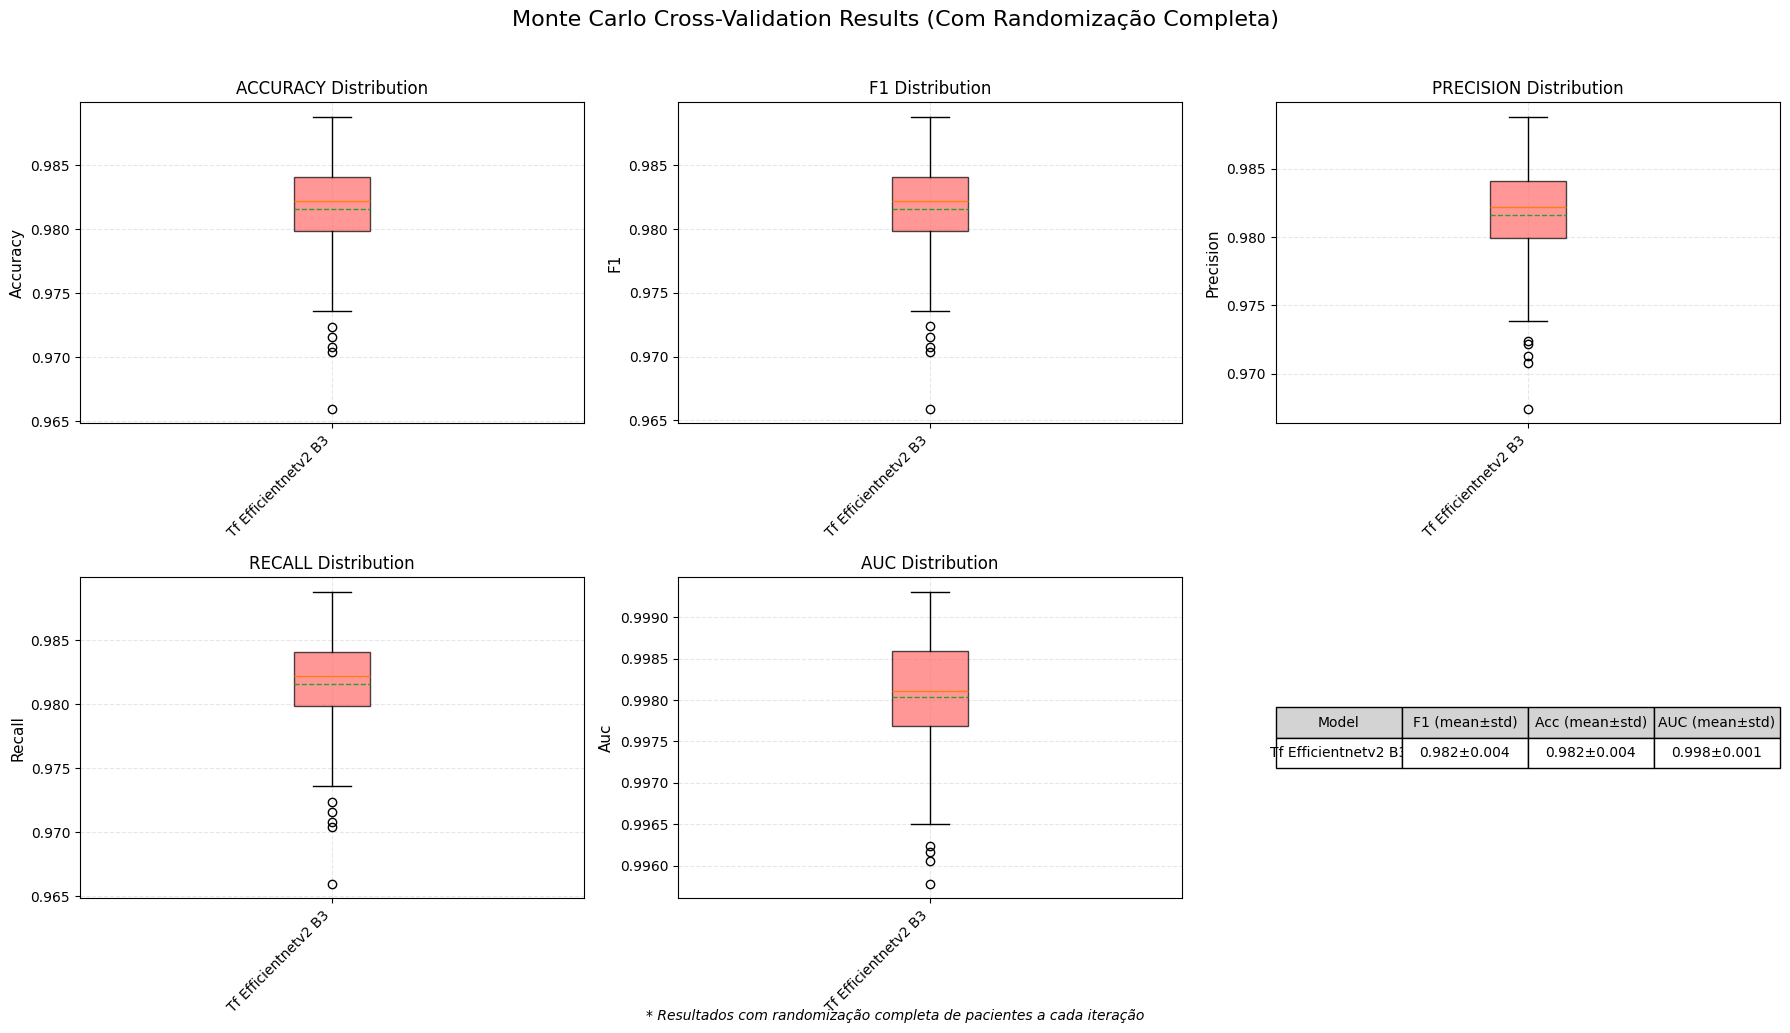

📊 Análise de convergência salva em: monte_carlo_results_randomized/convergence_analysis_randomized.png


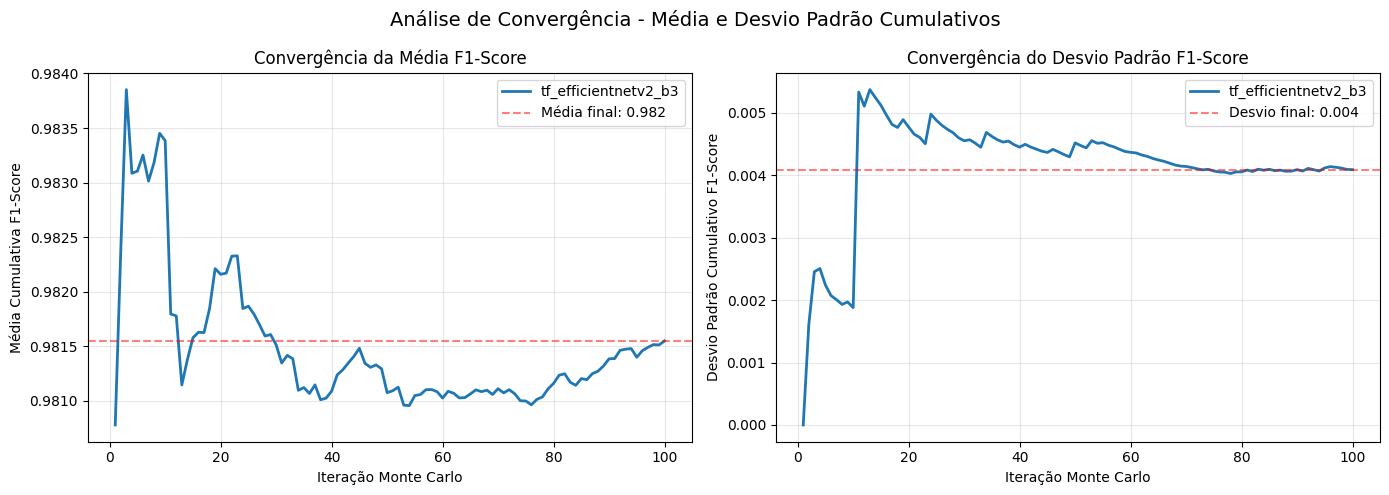

📄 Relatório salvo em: monte_carlo_results_randomized/monte_carlo_report_randomized.md

MONTE CARLO CROSS-VALIDATION CONCLUÍDO!
Resultados salvos em: monte_carlo_results_randomized


In [26]:
# ===================== FUNÇÃO PRINCIPAL =====================
def main():
    print("="*60)
    print("MONTE CARLO CROSS-VALIDATION COM RANDOMIZAÇÃO COMPLETA")
    print("="*60)
    print(f"Configuração:")
    print(f"- Iterações Monte Carlo: {MONTE_CARLO_ITERATIONS}")
    print(f"- Split: {(1-TEST_SIZE)*100:.0f}% treino+val, {TEST_SIZE*100:.0f}% teste")
    print(f"- Epochs por iteração: {EPOCHS_PER_ITERATION}")
    print(f"- Device: {DEVICE}")
    print(f"- Modelos: {CNN_MODELS}")
    print(f"- RANDOMIZAÇÃO: Completa a cada iteração")
    print("="*60)
    
    # Executar Monte Carlo CV para cada modelo
    all_results = {}
    
    for model_name in CNN_MODELS:
        try:
            results = run_monte_carlo_cv_randomized(model_name)
            all_results[model_name] = results
            
            # Imprimir resumo
            print(f"\n{'='*50}")
            print(f"RESUMO - {model_name}")
            print(f"{'='*50}")
            for metric in ['f1', 'accuracy', 'precision', 'recall', 'auc']:
                stats = results['statistics'][metric]
                print(f"{metric.upper():10s}: {stats['mean']:.4f} ± {stats['std']:.4f} "
                      f"[{stats['ci95_lower']:.4f}, {stats['ci95_upper']:.4f}]")
            
            # Comparação com resultados anteriores
            print(f"\n⚠️ COMPARAÇÃO COM RESULTADOS SEM RANDOMIZAÇÃO:")
            print(f"Anterior: F1 = 0.9728 ± 0.0044")
            print(f"Atual:    F1 = {stats['mean']:.4f} ± {stats['std']:.4f}")
            print(f"Diferença no desvio padrão: {stats['std']/0.0044:.1f}x maior")
            
        except Exception as e:
            print(f"❌ Erro ao processar {model_name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Gerar visualizações
    if all_results:
        plot_monte_carlo_results(all_results)
        plot_convergence_analysis(all_results)
    
    # Salvar resultados consolidados
    consolidated_path = os.path.join(SAVE_DIR, 'all_models_mc_results_randomized.pkl')
    with open(consolidated_path, 'wb') as f:
        pickle.dump(all_results, f)
    
    # Gerar relatório final
    generate_final_report(all_results)
    
    print("\n" + "="*60)
    print("MONTE CARLO CROSS-VALIDATION CONCLUÍDO!")
    print(f"Resultados salvos em: {SAVE_DIR}")
    print("="*60)

if __name__ == "__main__":
    main()